In [2]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('Ventas_A_Anual_Limpia.csv') 

In [5]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nombre vendedor  52 non-null     str    
 1   Acum             52 non-null     int64  
 2   Raking           52 non-null     float64
 3   Acum 2024        52 non-null     float64
 4   Ranking 2024     52 non-null     float64
 5   Acum 2025        52 non-null     float64
 6   Ranking 2025     52 non-null     float64
 7   Acum 2026        52 non-null     float64
 8   Ranking 2026     52 non-null     float64
dtypes: float64(7), int64(1), str(1)
memory usage: 3.8 KB


In [ ]:
#Se observa que la columna "Acum" esta como int64, por lo que se procede a cambiar el tipo de dato a float64. Ya que en el excel es un dato generado igual que todos los demás 'Acum'.
#Primero se revisa que todos los datos de la columna "Acum" sean numericos, para poder hacer el cambio de tipo de dato.
data['Acum'].unique()

array([ 88,  28,  98,  25,  46,  72,  63,  16,  15,  20,  12,   8,   7,
         6,   3,   2,   4,   1,  14,   9,  29,   5,  10,  13,  26, 811])

In [ ]:
#Se confirma que todos los datos de la columna "Acum" son numericos, por lo que se procede a cambiar el tipo de dato a float64.
data['Acum'] = data['Acum'].astype(float)

In [8]:
#Se corrobora el cambio de tipo de dato de la columna "Acum" a float64
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nombre vendedor  52 non-null     str    
 1   Acum             52 non-null     float64
 2   Raking           52 non-null     float64
 3   Acum 2024        52 non-null     float64
 4   Ranking 2024     52 non-null     float64
 5   Acum 2025        52 non-null     float64
 6   Ranking 2025     52 non-null     float64
 7   Acum 2026        52 non-null     float64
 8   Ranking 2026     52 non-null     float64
dtypes: float64(8), str(1)
memory usage: 3.8 KB


In [23]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Nombre vendedor    0
Acum               0
Raking             0
Acum 2024          0
Ranking 2024       0
Acum 2025          0
Ranking 2025       0
Acum 2026          0
Ranking 2026       0
dtype: int64

División de cualitativas y cuantitativas

In [18]:
#Creo 2 dataframe para poder procesar los outliers, separando las variables cualitativas de las cuantitativas
cualitativas = data['Nombre vendedor']
cuantitativas = data.iloc[:, 1:9]


In [ ]:
#Se corroboran los dataframes creados
cualitativas.head()

0      PEDRO GONZALEZ ESPINDOLA
1    VICTOR MANUEL SANCHEZ ARRO
2      MIGUEL ANGEL SONDEREGGER
3     JOSE ANTONIO LICONA MENDE
4         JAIME GONZALEZ CORONA
Name: Nombre vendedor, dtype: str

In [ ]:
#Se corroboran los dataframes creados
cuantitativas.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Acum          52 non-null     float64
 1   Raking        52 non-null     float64
 2   Acum 2024     52 non-null     float64
 3   Ranking 2024  52 non-null     float64
 4   Acum 2025     52 non-null     float64
 5   Ranking 2025  52 non-null     float64
 6   Acum 2026     52 non-null     float64
 7   Ranking 2026  52 non-null     float64
dtypes: float64(8)
memory usage: 3.4 KB


Se indentifican los outliers

<Figure size 1500x800 with 0 Axes>

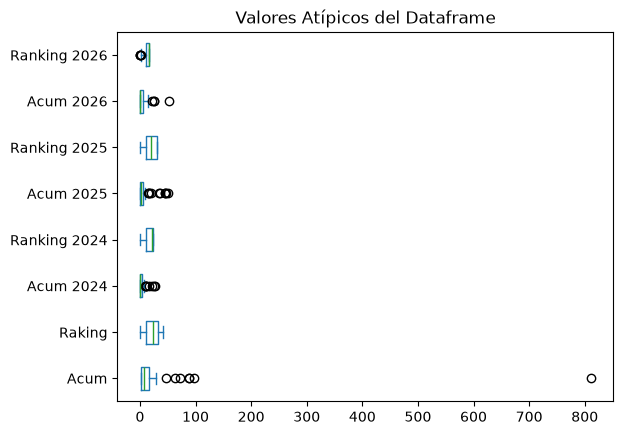

In [24]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

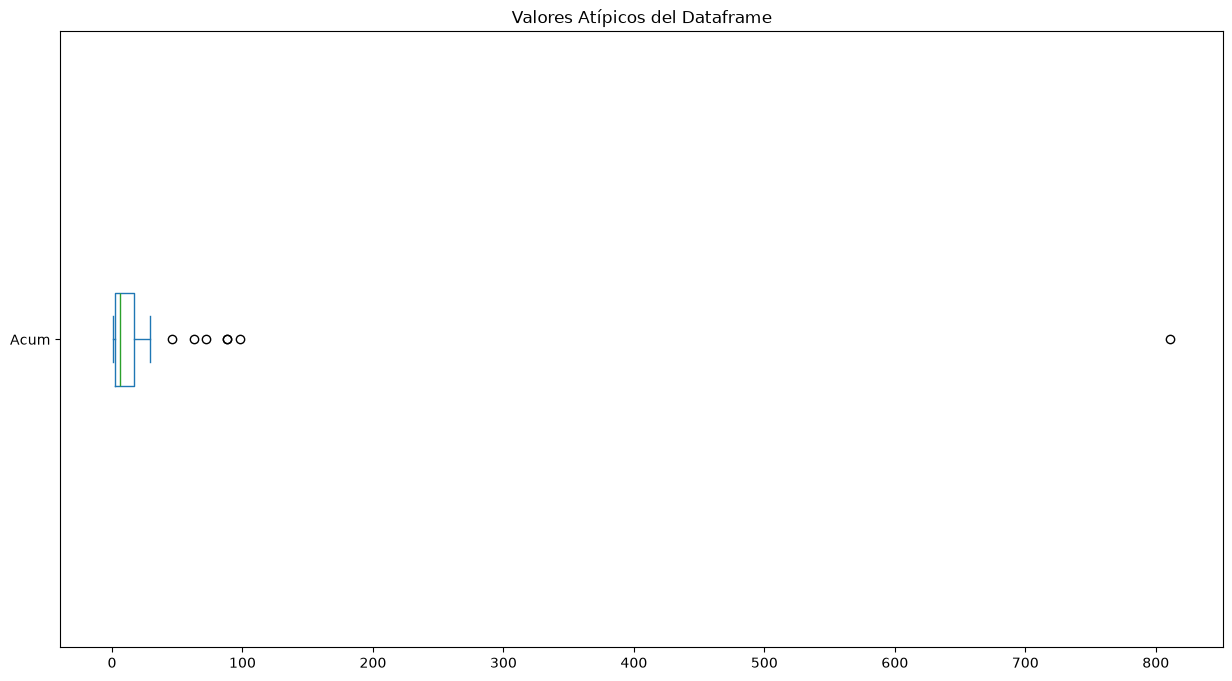

In [25]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas['Acum'].plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [30]:
#Se observa que en Acum hay un valor atípico, bastante alejado del resto de los datos, se revisó en el excel y es la suma de todos los acumulados. Se considera que esta fila trae ruido a la base de datos, por lo que se decide eliminarla. Se procede a eliminar la fila con el valor atípico de la columna "Acum".
data = data[
    data['Nombre vendedor'] != 'Total general'
]

In [31]:
data.tail()

,Nombre vendedor,Acum,Raking,Acum 2024,Ranking 2024,Acum 2025,Ranking 2025,Acum 2026,Ranking 2026
46,NAYELI,13.0,14.0,0.0,24.0,0.0,30.0,13.0,4.0
47,PEDRO ANTONIO,26.0,7.0,0.0,24.0,15.0,8.0,11.0,7.0
48,OBRIAN,2.0,32.0,0.0,24.0,0.0,30.0,2.0,14.0
49,FATIMA,2.0,32.0,0.0,24.0,0.0,30.0,2.0,14.0
50,RUBEN,1.0,41.0,0.0,24.0,0.0,30.0,1.0,16.0


In [32]:
Q1 = data['Acum'].quantile(0.25)
Q3 = data['Acum'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = data[
    (data['Acum'] < limite_inferior) |
    (data['Acum'] > limite_superior)
]

outliers

,Nombre vendedor,Acum,Raking,Acum 2024,Ranking 2024,Acum 2025,Ranking 2025,Acum 2026,Ranking 2026
0,PEDRO GONZALEZ ESPINDOLA,88.0,0.0,22.0,0.0,45.0,2.0,21.0,0.0
1,VICTOR MANUEL SANCHEZ ARRO,88.0,0.0,11.0,0.0,51.0,0.0,26.0,0.0
3,JOSE ANTONIO LICONA MENDE,98.0,1.0,10.0,4.0,35.0,4.0,53.0,1.0
5,ALAN GONZÁLEZ BELANZATEGU,46.0,4.0,4.0,10.0,36.0,3.0,6.0,11.0
6,MAURICIO ALFREDO VAZQUEZ F,72.0,2.0,0.0,24.0,47.0,1.0,25.0,2.0
7,AURELIO FELIPE TORRES REV,63.0,3.0,3.0,12.0,45.0,2.0,15.0,3.0


In [ ]:
# Se detectaron estos valores como estadísticamente atípicos, pero se decidió conservarlos porque corresponden a diferencias reales en el desempeño de los asesores.

In [33]:
#Se descarga el dataframe sin los valores atípicos a un archivo .csv
data.to_csv("ventas_a_anual_sin_outliers.csv", index=False)